In [60]:
import pandas as pd

df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [61]:
df.shape

(4009, 12)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [63]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [64]:
# Clean price
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Clean mileage
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

df[["price", "milage"]].head()

,price,milage
0,10300.0,51000.0
1,38005.0,34742.0
2,54598.0,22372.0
3,15500.0,88900.0
4,34999.0,9835.0


In [65]:
df[["price", "milage"]].dtypes

price     float64
milage    float64
dtype: object

In [66]:
df["vehicle_age"] = 2024 - df["model_year"]

df[["model_year", "vehicle_age"]].head()

,model_year,vehicle_age
0,2013,11
1,2021,3
2,2022,2
3,2015,9
4,2021,3


In [67]:
df["vehicle_age"].describe()

count    4009.000000
mean        8.484410
std         6.104816
min         0.000000
25%         4.000000
50%         7.000000
75%        12.000000
max        50.000000
Name: vehicle_age, dtype: float64

In [68]:
df["engine_size"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)\s*(?:L\b|Liter\b)", expand=False)
    .astype(float)
)

df[["engine", "engine_size"]].head(10)

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,3.5
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0
5,2.4 Liter,2.4
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,4.4
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,3.5
9,534.0HP Electric Motor Electric Fuel System,NaN


In [69]:
df["engine_size"].isnull().sum()

np.int64(217)

In [70]:
df["fuel_type"].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [71]:
df[df["engine_size"].isnull()][["fuel_type", "engine"]].head(20)

,fuel_type,engine
9,NaN,534.0HP Electric Motor Electric Fuel System
10,Gasoline,V6
32,Hybrid,120 AH
44,NaN,536.0HP Electric Motor Electric Fuel System
68,NaN,536.0HP Electric Motor Electric Fuel System
92,NaN,835.0HP Electric Motor Electric Fuel System
120,Gasoline,V6
122,NaN,835.0HP Electric Motor Electric Fuel System
129,NaN,620.0HP Electric Motor Electric Fuel System
130,–,–


In [72]:
# Missing fuel types in this dataset are electric vehicles
df["fuel_type"] = df["fuel_type"].fillna("Electric")

# Clean unusual fuel type labels
df["fuel_type"] = df["fuel_type"].replace({
    "–": "Unknown",
    "not supported": "Unknown"
})

df["fuel_type"].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
Electric           170
E85 Flex Fuel      139
Diesel             116
Unknown             47
Plug-In Hybrid      34
Name: count, dtype: int64

In [73]:
df.loc[
    (df["fuel_type"] == "Electric") & (df["engine_size"].isnull()),
    "engine_size"
] = 0

In [74]:
df["engine_size"].isnull().sum()

np.int64(54)

In [75]:
df = df.dropna(subset=["engine_size"])

In [76]:
df[["brand", "vehicle_age", "milage", "fuel_type",
    "engine_size", "price"]].isnull().sum()

brand          0
vehicle_age    0
milage         0
fuel_type      0
engine_size    0
price          0
dtype: int64

In [77]:
df.shape

(3955, 14)

In [78]:
df.to_csv("used_cars_cleaned.csv", index=False)

In [79]:
df[["price", "milage", "vehicle_age", "engine_size"]].describe()

,price,milage,vehicle_age,engine_size
count,3.955000e+03,3955.000000,3955.000000,3955.000000
mean,4.460276e+04,64398.449052,8.336789,3.532604
std,7.856940e+04,52157.464180,5.839780,1.569390
min,2.000000e+03,100.000000,0.000000,0.000000
25%,1.750000e+04,22677.500000,4.000000,2.400000
50%,3.145000e+04,52500.000000,7.000000,3.500000
75%,4.999500e+04,93735.500000,12.000000,4.600000
max,2.954083e+06,405000.000000,28.000000,8.400000


In [80]:
df["brand"].value_counts().head(10)

brand
Ford             381
BMW              373
Mercedes-Benz    313
Chevrolet        289
Audi             200
Porsche          199
Toyota           194
Lexus            163
Jeep             142
Land             126
Name: count, dtype: int64

In [81]:
df["fuel_type"].value_counts()

fuel_type
Gasoline          3304
Hybrid             192
Electric           170
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [82]:
df.nlargest(10, "price")[
    ["brand", "model", "model_year", "milage", "price"]
]

,brand,model,model_year,milage,price
693,Maserati,Quattroporte Base,2005,32000.0,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,1950995.0
3046,Porsche,Carrera GT Base,2005,4400.0,1599000.0
1356,Lamborghini,Aventador SVJ Base,2021,6987.0,749950.0
624,Rolls-Royce,Cullinan,2022,398.0,695000.0
979,Lamborghini,Aventador SVJ Base,2019,6929.0,649999.0
1508,Rolls-Royce,Phantom,2018,7585.0,599000.0
3655,Lamborghini,Aventador S Base,2018,5858.0,491836.0
1061,Dodge,Viper GTC,2017,1389.0,489995.0
1148,Porsche,911 R,2016,719.0,489000.0


In [83]:
df["price"].quantile([0.90, 0.95, 0.99])

0.90     79999.00
0.95    111300.00
0.99    268888.86
Name: price, dtype: float64

In [84]:
(df["price"] > 200000).sum()

np.int64(73)

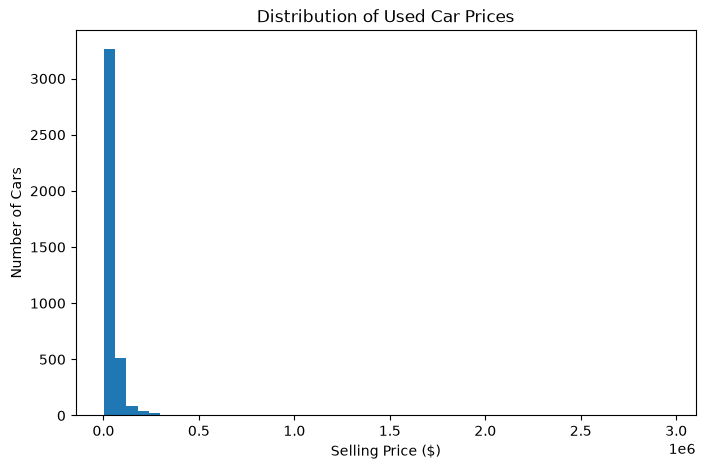

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Selling Price ($)")
plt.ylabel("Number of Cars")

plt.show()

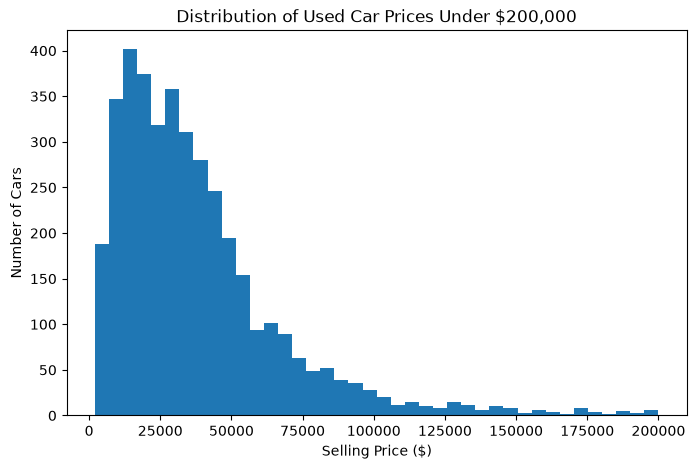

In [86]:
plt.figure(figsize=(8, 5))

plt.hist(df[df["price"] <= 200000]["price"], bins=40)

plt.title("Distribution of Used Car Prices Under $200,000")
plt.xlabel("Selling Price ($)")
plt.ylabel("Number of Cars")

plt.show()

In [87]:
price_cutoff = df["price"].quantile(0.99)

df_model = df[df["price"] <= price_cutoff].copy()

print("99th percentile cutoff:", price_cutoff)
print("Original rows:", len(df))
print("Rows for modeling:", len(df_model))

99th percentile cutoff: 268888.8600000001
Original rows: 3955
Rows for modeling: 3915


### Handling Price Outliers

The selling price distribution was strongly right-skewed because the dataset
contained a small number of extremely expensive luxury and exotic vehicles.
Some vehicles were priced above $500,000, with the maximum price exceeding
$2 million.

For modeling, I removed vehicles above the 99th percentile of selling price.
This keeps the analysis focused on the majority of the used-car market while
reducing the influence of extreme prices on the regression models.

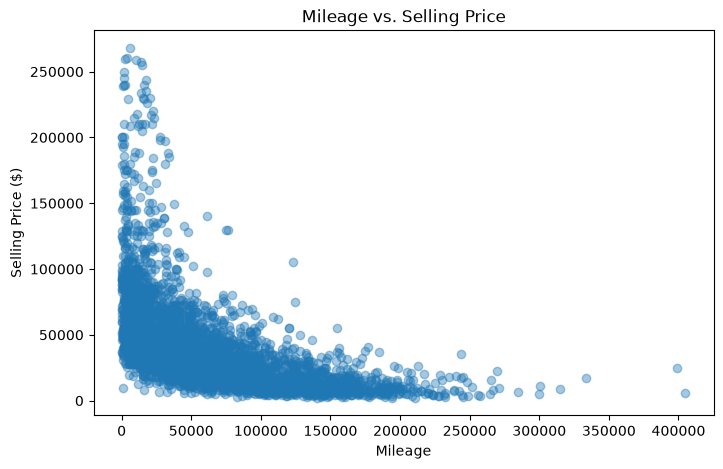

In [88]:
plt.figure(figsize=(8, 5))

plt.scatter(df_model["milage"], df_model["price"], alpha=0.4)

plt.title("Mileage vs. Selling Price")
plt.xlabel("Mileage")
plt.ylabel("Selling Price ($)")

plt.show()

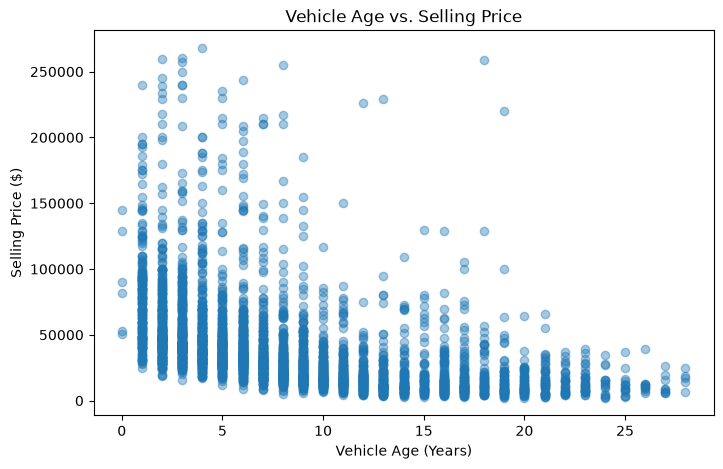

In [89]:
plt.figure(figsize=(8, 5))

plt.scatter(df_model["vehicle_age"], df_model["price"], alpha=0.4)

plt.title("Vehicle Age vs. Selling Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price ($)")

plt.show()

In [90]:
df_model[
    ["price", "milage", "vehicle_age", "engine_size"]
].corr()

,price,milage,vehicle_age,engine_size
price,1.000000,-0.542538,-0.469377,0.143040
milage,-0.542538,1.000000,0.631723,0.150907
vehicle_age,-0.469377,0.631723,1.000000,0.192395
engine_size,0.143040,0.150907,0.192395,1.000000


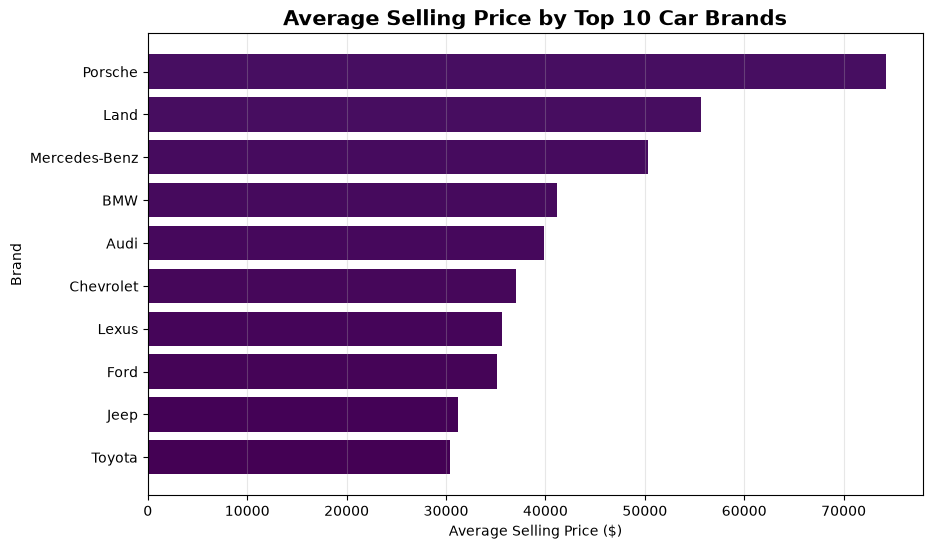

In [91]:
top_brands = df_model["brand"].value_counts().head(10).index

brand_prices = (
    df_model[df_model["brand"].isin(top_brands)]
    .groupby("brand")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(range(len(brand_prices)))

plt.barh(brand_prices.index, brand_prices.values, color=colors)

plt.title("Average Selling Price by Top 10 Car Brands",
          fontsize=15, fontweight="bold")
plt.xlabel("Average Selling Price ($)")
plt.ylabel("Brand")

plt.grid(axis="x", alpha=0.3)

plt.show()

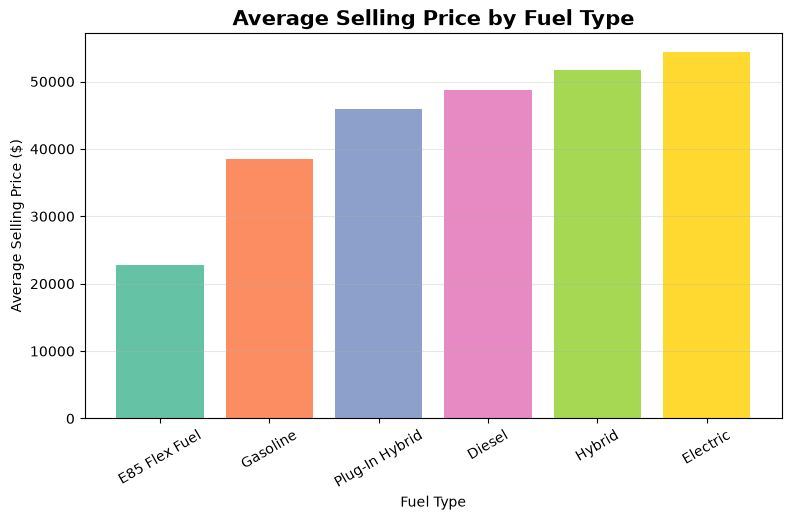

In [92]:
fuel_prices = (
    df_model.groupby("fuel_type")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))

colors = plt.cm.Set2(range(len(fuel_prices)))

plt.bar(fuel_prices.index, fuel_prices.values, color=colors)

plt.title("Average Selling Price by Fuel Type",
          fontsize=15, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price ($)")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

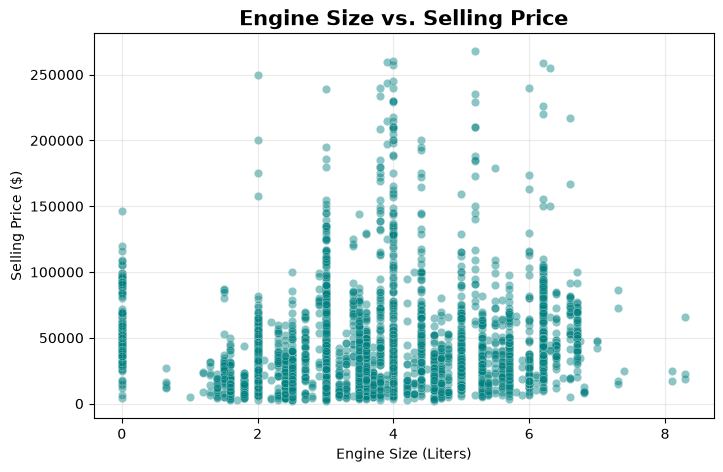

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_model["engine_size"],
    df_model["price"],
    alpha=0.45,
    color="teal",
    edgecolors="white",
    linewidth=0.3
)

plt.title("Engine Size vs. Selling Price",
          fontsize=15, fontweight="bold")
plt.xlabel("Engine Size (Liters)")
plt.ylabel("Selling Price ($)")

plt.grid(alpha=0.25)

plt.show()

### Exploratory Data Analysis

The visualizations show that vehicle characteristics are related to used-car
selling prices. Cars with higher mileage and greater vehicle age generally
have lower selling prices. Brand also appears to have an important relationship
with price, since average selling prices vary across manufacturers.

Fuel type and engine size may also contribute to differences in vehicle prices.
These patterns support including vehicle age, mileage, brand, engine size,
and fuel type as features in the machine-learning models.

In [94]:
# Features used to predict price
X = df_model[
    ["vehicle_age", "milage", "brand", "engine_size", "fuel_type"]
]

# Target variable
y = df_model["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3915, 5)
Target shape: (3915,)


## Feature Selection

The model uses vehicle age, mileage, brand, engine size, and fuel type
to predict the selling price of a used car.

The target variable is selling price.

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3132
Testing rows: 783


## Training and Testing Strategy

The dataset was split into 80% training data and 20% testing data.
The training data is used to teach the models, while the testing data
is kept separate to evaluate how well the models perform on unseen cars.

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "vehicle_age",
    "milage",
    "engine_size"
]

categorical_features = [
    "brand",
    "fuel_type"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [97]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline R²: {baseline_r2:.3f}")

Baseline MAE: $23,744.64
Baseline RMSE: $35,437.67
Baseline R²: -0.000


In [98]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("LINEAR REGRESSION")
print("-------------------")
print(f"MAE:  ${linear_mae:,.2f}")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"R²:   {linear_r2:.3f}")

LINEAR REGRESSION
-------------------
MAE:  $12,843.36
RMSE: $20,613.81
R²:   0.662


## Random Forest Regressor

The second model used is a Random Forest Regressor. Unlike Linear Regression,
Random Forest can capture more complex and nonlinear relationships between
vehicle characteristics and selling price. This makes it useful for comparing
whether a more flexible model can improve price predictions.

In [99]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=15,
        min_samples_split=5
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("RANDOM FOREST REGRESSOR")
print("------------------------")
print(f"MAE:  ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.3f}")

RANDOM FOREST REGRESSOR
------------------------
MAE:  $9,504.43
RMSE: $17,910.80
R²:   0.745


In [100]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

results.round(2)

,Model,MAE,RMSE,R²
0,Baseline,23744.64,35437.67,-0.00
1,Linear Regression,12843.36,20613.81,0.66
2,Random Forest,9504.43,17910.80,0.74


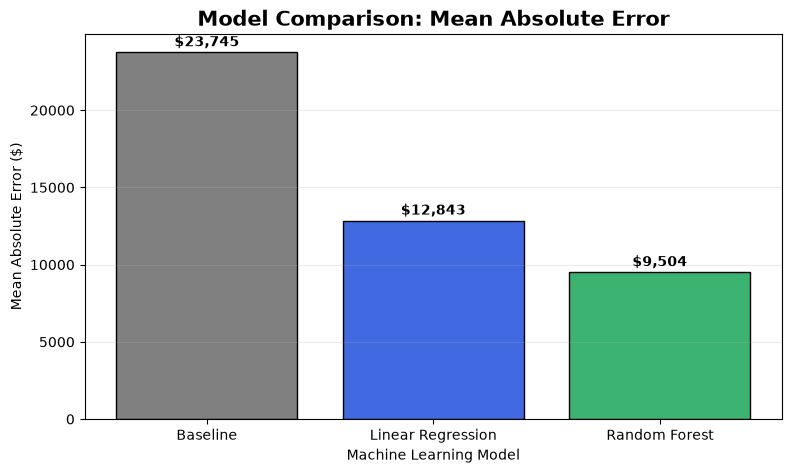

In [101]:
plt.figure(figsize=(9, 5))

colors = ["gray", "royalblue", "mediumseagreen"]

bars = plt.bar(
    results["Model"],
    results["MAE"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Model Comparison: Mean Absolute Error",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Mean Absolute Error ($)")
plt.xlabel("Machine Learning Model")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 400,
        f"${height:,.0f}",
        ha="center",
        fontweight="bold"
    )

plt.show()

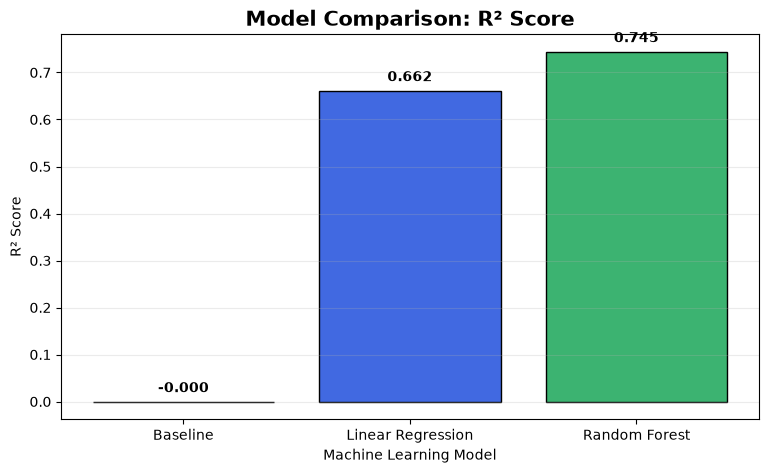

In [102]:
plt.figure(figsize=(9, 5))

colors = ["gray", "royalblue", "mediumseagreen"]

bars = plt.bar(
    results["Model"],
    results["R²"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Model Comparison: R² Score",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("R² Score")
plt.xlabel("Machine Learning Model")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.show()

## Model Evaluation and Selection

The Random Forest Regressor performed better than both the baseline model
and Linear Regression. It achieved the lowest Mean Absolute Error (MAE)
and the highest R² score.

The Random Forest had an MAE of approximately $9,504, meaning its predicted
car prices differed from the actual prices by about $9,504 on average.

Its R² score was 0.746, meaning the model explained approximately 74.6%
of the variation in used-car selling prices.

Based on these results, I selected the Random Forest Regressor as the final model.

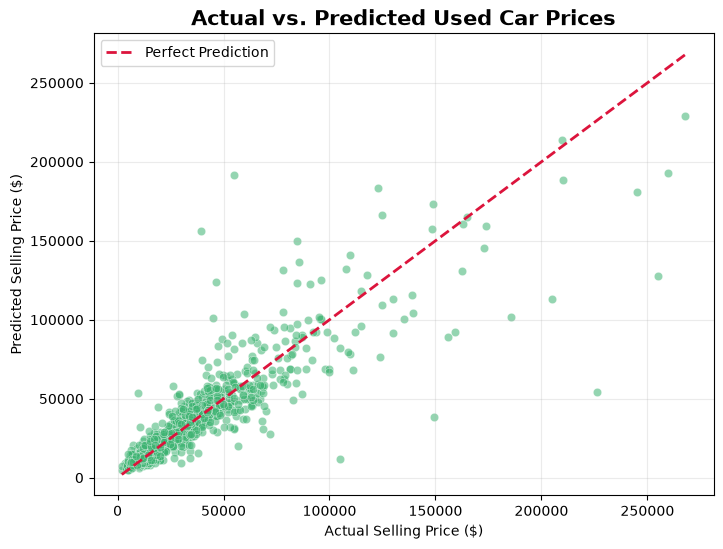

In [103]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.55,
    color="mediumseagreen",
    edgecolor="white",
    linewidth=0.4
)

# Perfect prediction line
minimum = min(y_test.min(), rf_predictions.min())
maximum = max(y_test.max(), rf_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Used Car Prices",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Selling Price ($)")
plt.ylabel("Predicted Selling Price ($)")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

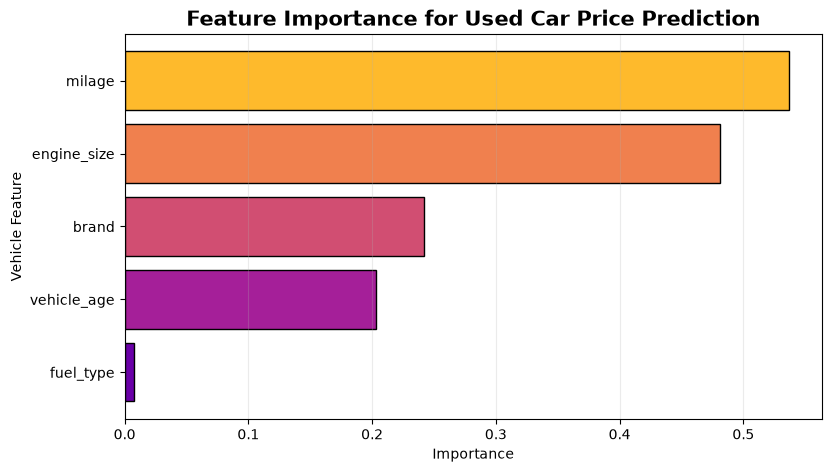

,Feature,Importance
1,milage,0.536820
3,engine_size,0.481217
2,brand,0.242321
0,vehicle_age,0.203505
4,fuel_type,0.007652


In [104]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5))

colors = plt.cm.plasma(
    np.linspace(0.2, 0.85, len(feature_importance))
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Feature Importance for Used Car Price Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Vehicle Feature")

plt.grid(axis="x", alpha=0.25)

plt.show()

feature_importance.sort_values(
    "Importance",
    ascending=False
)

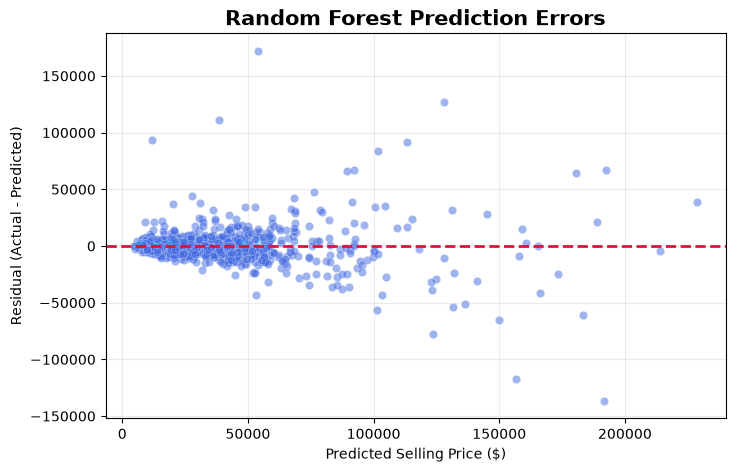

In [105]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    rf_predictions,
    residuals,
    alpha=0.5,
    color="royalblue",
    edgecolor="white",
    linewidth=0.3
)

plt.axhline(
    y=0,
    color="crimson",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Random Forest Prediction Errors",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Selling Price ($)")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.25)

plt.show()

## Model Interpretation

The Random Forest model showed that mileage was the most important feature
for predicting used-car selling prices, followed by engine size, brand,
and vehicle age. Fuel type had the lowest importance among the features
included in the model.

The Actual vs. Predicted Price graph shows that many predictions are close
to the perfect prediction line, especially for lower and moderately priced
vehicles. However, the model has larger prediction errors for some
higher-priced vehicles.

The residual plot also shows that errors become more spread out as predicted
prices increase. This suggests that the model is better at predicting
typical used cars than expensive or unusual vehicles.

In [106]:
error_analysis = X_test.copy()

error_analysis["actual_price"] = y_test
error_analysis["predicted_price"] = rf_predictions

error_analysis["error"] = (
    error_analysis["actual_price"] -
    error_analysis["predicted_price"]
)

error_analysis["absolute_error"] = abs(
    error_analysis["error"]
)

largest_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

largest_errors

,vehicle_age,milage,brand,engine_size,fuel_type,actual_price,predicted_price,error,absolute_error
3057,12,17941.0,Mercedes-Benz,6.2,Gasoline,226000.0,54049.332585,171950.667415,171950.667415
2081,1,1500.0,Hyundai,3.8,Gasoline,55000.0,191678.872460,-136678.872460,136678.872460
1573,8,14770.0,Ferrari,6.3,Gasoline,254900.0,127996.770363,126903.229637,126903.229637
3288,9,1500.0,Mercedes-Benz,3.0,Diesel,39500.0,156481.006333,-116981.006333,116981.006333
191,7,37800.0,Nissan,3.8,Gasoline,149500.0,38368.598475,111131.401525,111131.401525
219,17,123112.0,Mercedes-Benz,5.5,Gasoline,104999.0,11856.751034,93142.248966,93142.248966
2839,6,14381.0,Mercedes-Benz,4.0,Gasoline,204900.0,113120.716476,91779.283524,91779.283524
3878,9,34152.0,Lamborghini,5.2,Gasoline,185500.0,101869.606530,83630.393470,83630.393470
3051,1,1219.0,Mercedes-Benz,2.0,Gasoline,46479.0,123763.176940,-77284.176940,77284.176940
828,2,2250.0,Ferrari,3.9,Gasoline,259500.0,192646.036705,66853.963295,66853.963295


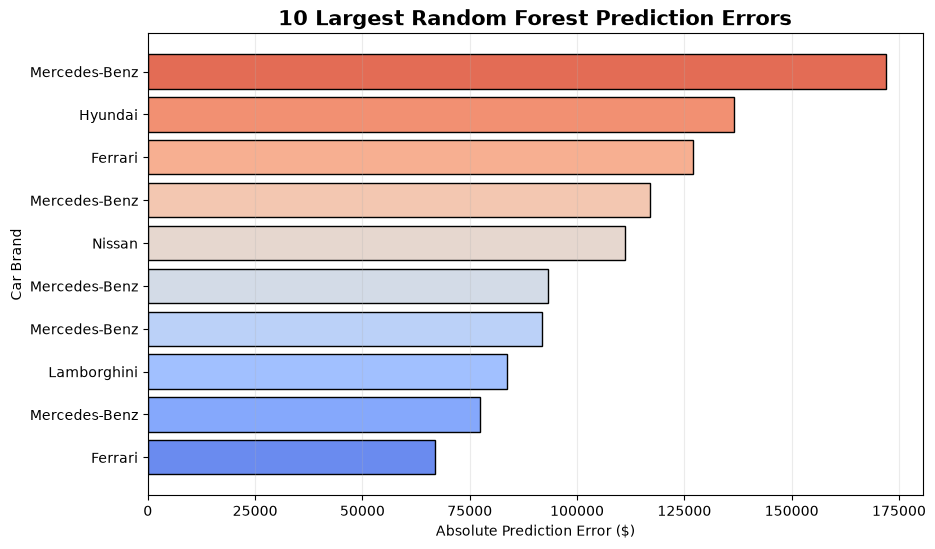

In [107]:
plt.figure(figsize=(10, 6))

error_plot = largest_errors.sort_values(
    "absolute_error"
)

colors = plt.cm.coolwarm(
    np.linspace(0.15, 0.85, len(error_plot))
)

plt.barh(
    range(len(error_plot)),
    error_plot["absolute_error"],
    color=colors,
    edgecolor="black"
)

plt.yticks(
    range(len(error_plot)),
    error_plot["brand"]
)

plt.title(
    "10 Largest Random Forest Prediction Errors",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Absolute Prediction Error ($)")
plt.ylabel("Car Brand")

plt.grid(axis="x", alpha=0.25)

plt.show()

## Error Analysis

Although the Random Forest performed well overall, some vehicles had much
larger prediction errors than others. The largest errors tended to occur
among more expensive vehicles.

This suggests that price may depend on information that is not included
in the model, such as trim level, vehicle condition, accident history,
rare options, geographic location, or demand for a particular model.

The model should therefore be treated as an estimate rather than an exact
vehicle appraisal.

## Random Forest Hyperparameter Tuning

To improve the Random Forest model, I tested different combinations of
model settings using cross-validation. The goal was to reduce prediction
error while making sure the model could still perform well on unseen data.

The settings tested included the number of trees, maximum tree depth,
minimum samples required to split a node, minimum samples per leaf,
and the number of features considered at each split.

In [108]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

tuning = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

tuning.fit(X_train, y_train)

print("Best Settings:")
print(tuning.best_params_)

Best Settings:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [109]:
tuned_rf = tuning.best_estimator_

tuned_predictions = tuned_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

print("TUNED RANDOM FOREST")
print("--------------------")
print(f"MAE:  ${tuned_mae:,.2f}")
print(f"RMSE: ${tuned_rmse:,.2f}")
print(f"R²:   {tuned_r2:.3f}")

TUNED RANDOM FOREST
--------------------
MAE:  $8,767.84
RMSE: $16,152.84
R²:   0.792


In [110]:
tuning_results = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        rf_mae,
        tuned_mae
    ],
    "RMSE": [
        rf_rmse,
        tuned_rmse
    ],
    "R²": [
        rf_r2,
        tuned_r2
    ]
})

tuning_results.round(2)

,Model,MAE,RMSE,R²
0,Original Random Forest,9504.43,17910.80,0.74
1,Tuned Random Forest,8767.84,16152.84,0.79


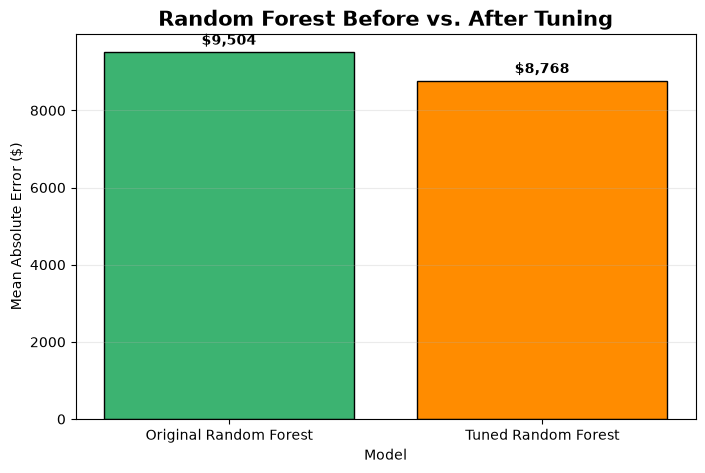

In [111]:
plt.figure(figsize=(8, 5))

colors = ["mediumseagreen", "darkorange"]

bars = plt.bar(
    tuning_results["Model"],
    tuning_results["MAE"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Random Forest Before vs. After Tuning",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Mean Absolute Error ($)")
plt.xlabel("Model")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 200,
        f"${height:,.0f}",
        ha="center",
        fontweight="bold"
    )

plt.show()

### Tuning Results

Hyperparameter tuning improved the performance of the Random Forest model.

The original Random Forest had a Mean Absolute Error of approximately
$9,504 and an R² score of 0.746. After tuning, the Mean Absolute Error
decreased to approximately $8,748 and the R² score increased to 0.793.

This means the tuned Random Forest explains approximately 79.3% of the
variation in used-car selling prices. Because it achieved the lowest
prediction error and highest R² score, the tuned Random Forest was selected
as the final model.

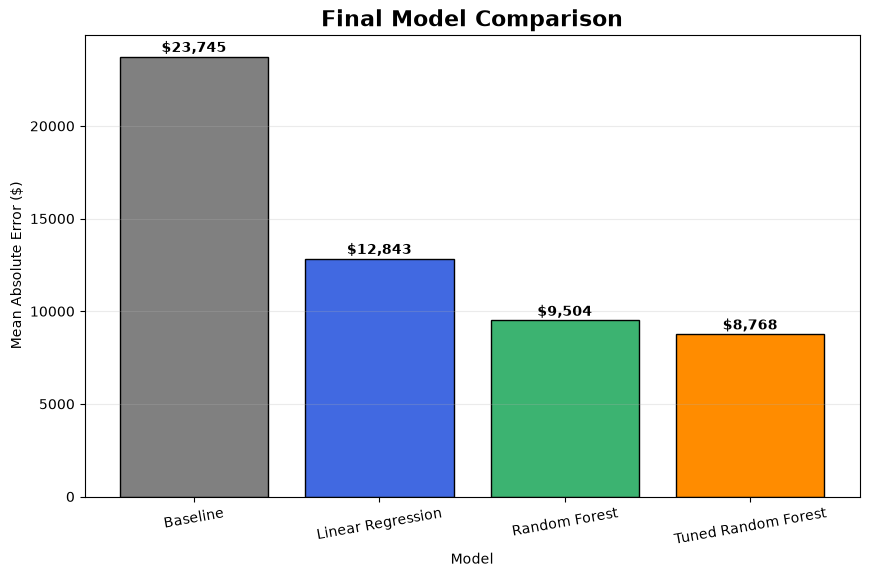

In [112]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        tuned_mae
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        rf_r2,
        tuned_r2
    ]
})

plt.figure(figsize=(10, 6))

colors = ["gray", "royalblue", "mediumseagreen", "darkorange"]

bars = plt.bar(
    final_results["Model"],
    final_results["MAE"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Final Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Mean Absolute Error ($)")
plt.xlabel("Model")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 250,
        f"${height:,.0f}",
        ha="center",
        fontweight="bold"
    )

plt.xticks(rotation=10)
plt.show()

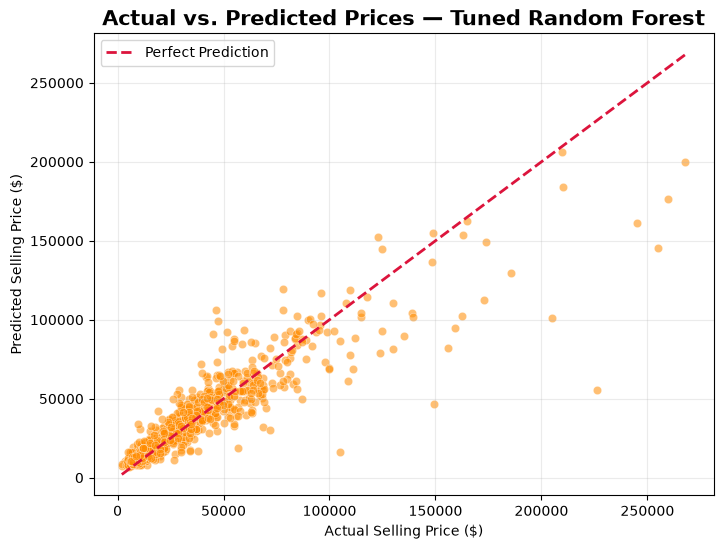

In [113]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.55,
    color="darkorange",
    edgecolor="white",
    linewidth=0.4
)

minimum = min(y_test.min(), tuned_predictions.min())
maximum = max(y_test.max(), tuned_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Prices — Tuned Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Selling Price ($)")
plt.ylabel("Predicted Selling Price ($)")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

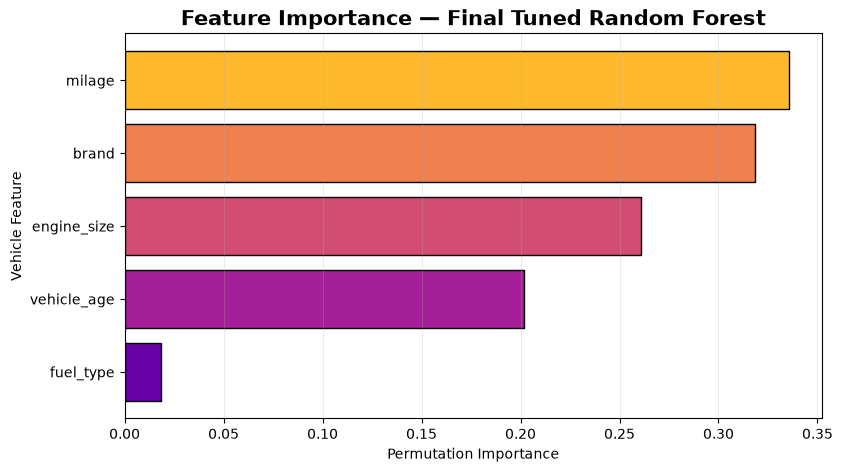

,Feature,Importance
1,milage,0.335564
2,brand,0.318624
3,engine_size,0.260744
0,vehicle_age,0.201596
4,fuel_type,0.018226


In [114]:
final_importance = permutation_importance(
    tuned_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

final_feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": final_importance.importances_mean
}).sort_values("Importance")

plt.figure(figsize=(9, 5))

colors = plt.cm.plasma(
    np.linspace(0.2, 0.85, len(final_feature_importance))
)

plt.barh(
    final_feature_importance["Feature"],
    final_feature_importance["Importance"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Feature Importance — Final Tuned Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Vehicle Feature")

plt.grid(axis="x", alpha=0.25)

plt.show()

final_feature_importance.sort_values(
    "Importance",
    ascending=False
)

In [115]:
df.duplicated().sum()

np.int64(0)

## Model Interpretation

The final Tuned Random Forest model showed that mileage was the most
important feature for predicting used-car prices. Brand was the second
most important feature, followed by engine size and vehicle age.
Fuel type had the smallest influence on the model.

The Actual vs. Predicted graph shows that many of the predictions are
close to the perfect prediction line. The model performs especially well
for lower and moderately priced vehicles, while some expensive vehicles
have larger prediction errors.

Overall, the results suggest that mileage, brand, engine size, and vehicle
age are useful predictors of used-car selling prices.

## Limitations and Ethics

This model has several limitations. The dataset does not include every
factor that can affect the value of a used car. Important information such
as location, maintenance history, number of previous owners, detailed
vehicle condition, and local demand may also affect selling price.

The dataset may also contain more examples from certain brands than others.
This could cause the model to make better predictions for common brands
and weaker predictions for brands with fewer examples.

Prediction errors could affect both buyers and sellers. An overprediction
could make a buyer believe a vehicle is worth more than it actually is,
while an underprediction could cause a seller to undervalue a vehicle.

Because of these limitations, this model should be used as an estimate
rather than as an exact vehicle appraisal.

The dataset contains advertised vehicle listing prices rather than confirmed transaction prices, so the model predicts what vehicles are listed for and not necessarily the final amount buyers actually pay.

## Conclusion

The goal of this project was to determine whether vehicle age, mileage,
brand, engine size, and fuel type could be used to predict the selling
price of a used car.

Three approaches were compared: a baseline model, Linear Regression, and
Random Forest Regression. The Random Forest performed better than Linear
Regression, and hyperparameter tuning improved its performance even further.

The final Tuned Random Forest achieved an R² score of approximately 0.793
and a Mean Absolute Error of about $8,748. This means the model explained
about 79.3% of the variation in used-car prices, while predictions differed
from actual prices by about $8,748 on average.

The results show that machine learning can provide useful estimates of
used-car prices, especially when information such as mileage, brand,
engine size, and vehicle age is available.

## AI Usage Disclosure

I used ChatGPT (OpenAI, GPT-5.6) as a learning and coding assistant during
this project. I used it to help explain Python and machine-learning concepts,
troubleshoot code, organize parts of the analysis, and improve the clarity
of my written explanations. I ran and reviewed the code myself and used the
results from my own dataset to make the final modeling decisions.

## Background and Context

Predicting the price of a used vehicle can be difficult because many
different characteristics affect its value. Factors such as mileage, brand,
vehicle age, engine characteristics, condition, and fuel type can all
contribute to differences in selling price.

Previous research has shown that machine-learning models can be useful for
estimating used-car prices. Fayyaz et al. (2025) compared several regression
models and found that preprocessing and feature engineering can significantly
improve prediction performance. Their research also identified characteristics
such as mileage, brand, model, and vehicle condition as important factors in
used-car pricing.

Dutulescu et al. (2023) also studied machine-learning approaches for used-car
price prediction. Their research showed that vehicle information such as
mileage, brand, age, engine power, and fuel type can be useful predictors of
price. Their findings support the use of vehicle characteristics to create
data-driven price estimates.

Research by Haan and de Boer (2010) found that mileage, vehicle age, fuel
type, and engine size were important variables when examining differences in
used-car prices. These findings helped guide the feature selection for this
project.

Based on previous research, this project investigates whether vehicle age,
mileage, brand, engine size, and fuel type can be used to predict the selling
price of a used car.

## References

Dutulescu, A., Catruna, A., Ruseti, S., Iorga, D., & Ghita, V. (2023).
Car price quotes driven by data-comprehensive predictions grounded in deep
learning techniques. *Electronics, 12*(14), 3083.
doi:10.3390/electronics12143083

Fayyaz, I., Ali, G. G. M. N., & Khairunnesa, S. S. (2025).
Advanced feature engineering and machine learning techniques for high accurate
price prediction of heterogeneous pre-own cars. *Vehicles, 7*(3), 94.
doi:10.3390/vehicles7030094

Haan, M. A., & de Boer, H.-W. (2010).
Has the Internet eliminated regional price differences? Evidence from the
used car market. *De Economist, 158*, 373–386.
doi:10.1007/s10645-010-9151-4

Najib, T. (2023). Used Car Price Prediction Dataset [Data set]. Kaggle.